# 2.5 Part A: Designing and Analyzing Convolutional Neural Networks from Scratch.

This section focuses on designing, training, and evaluating convolutional neural networks (CNNs) from scratch. You will first build a baseline model with a simple architecture, then extend it into a deeper model with regularization to analyze performance improvements. A thorough experimentation section will guide comparative analysis of different architectures and optimizers.

**Answer:** The work below uses a traffic sign image dataset and implements the required CNN experiments in the same order as the assessment brief.

## 2.5.1 Data Understanding, Analysis, Visualization and Cleaning:

Before building models, analyze and understand the dataset by answering the following questions:

**What does the dataset represent? Provide a brief description.**

**Answer:** The dataset represents a multi-class traffic sign image classification task. Each valid labeled image belongs to one of five categories: Cautions, Crossings, DIrection, No Entry, and SpeedLimit. The goal is to train models that can classify traffic sign images correctly.

**Notebook setup used for the answers below.**

**Answer:** The setup imports all required libraries, fixes random seeds for reproducibility, locates the dataset folder, and defines the image sizes, batch size, split settings, and output folder.

In [1]:
# Core imports
from pathlib import Path
import time
import math
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from PIL import Image, UnidentifiedImageError
from IPython.display import display

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator

from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import precision_recall_fscore_support
from sklearn.utils.class_weight import compute_class_weight

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)


In [3]:
# Dataset paths and main experiment settings
from google.colab import drive
drive.mount('/content/drive')
NOTEBOOK_DIR=Path('/content/drive/MyDrive/ai/notebook')
DATASET_DIR = (
    Path('/content/drive/MyDrive/ai/Traffic_Sign_-2')
)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [4]:


TRAIN_DIR = DATASET_DIR / 'Train'
ORIGINAL_TEST_DIR = DATASET_DIR / 'Test'
OUTPUT_DIR = NOTEBOOK_DIR / 'outputs'
OUTPUT_DIR.mkdir(exist_ok=True)

SCRATCH_IMG_SIZE = (128, 128)
TRANSFER_IMG_SIZE = (224, 224)
BATCH_SIZE = 32

PSEUDO_TEST_SIZE = 0.20
VALIDATION_SIZE_FROM_REMAINING = 0.20

BASELINE_EPOCHS = 10
DEEP_EPOCHS = 10
OPTIMIZER_EPOCHS = 8
ABLATION_EPOCHS = 8
TRANSFER_EPOCHS = 8
FINE_TUNE_EPOCHS = 5

print('Dataset directory:', DATASET_DIR)
print('Training folder:', TRAIN_DIR)
print('Original test folder:', ORIGINAL_TEST_DIR)

Dataset directory: /content/drive/MyDrive/ai/Traffic_Sign_-2
Training folder: /content/drive/MyDrive/ai/Traffic_Sign_-2/Train
Original test folder: /content/drive/MyDrive/ai/Traffic_Sign_-2/Test


**How many total images are in the dataset?**

**Answer:** Before cleanup, the dataset contains 16,100 image files in the labeled training folder and 10 image files in the original unlabeled Test folder. The next cell audits corrupted images first, prints the counts, deletes them from the dataset, and then rebuilds the clean dataframes for the rest of the notebook.

In [5]:
# Corrupted image audit and clean dataset rebuild
IMAGE_EXTENSIONS = {'.png', '.jpg', '.jpeg', '.bmp', '.webp'}


def inspect_image(path: Path):
    try:
        with Image.open(path) as image:
            image.verify()
        with Image.open(path) as image:
            return True, image.size, image.mode, None
    except (UnidentifiedImageError, OSError, ValueError) as exc:
        return False, None, None, str(exc)


def collect_labeled_images(train_dir: Path):
    valid_rows = []
    corrupted_rows = []
    for class_dir in sorted([p for p in train_dir.iterdir() if p.is_dir()]):
        for image_path in sorted(class_dir.iterdir()):
            if image_path.suffix.lower() not in IMAGE_EXTENSIONS:
                continue
            valid, size, mode, error = inspect_image(image_path)
            row = {
                'filepath': str(image_path.resolve()),
                'filename': image_path.name,
                'class_name': class_dir.name,
                'width': size[0] if size else np.nan,
                'height': size[1] if size else np.nan,
                'mode': mode,
                'valid': valid,
                'error': error
            }
            if valid:
                valid_rows.append(row)
            else:
                corrupted_rows.append(row)
    return pd.DataFrame(valid_rows), pd.DataFrame(corrupted_rows)


def collect_unlabeled_images(test_dir: Path):
    valid_rows = []
    corrupted_rows = []
    for image_path in sorted(test_dir.iterdir()):
        if not image_path.is_file() or image_path.suffix.lower() not in IMAGE_EXTENSIONS:
            continue
        valid, size, mode, error = inspect_image(image_path)
        row = {
            'filepath': str(image_path.resolve()),
            'filename': image_path.name,
            'width': size[0] if size else np.nan,
            'height': size[1] if size else np.nan,
            'mode': mode,
            'valid': valid,
            'error': error
        }
        if valid:
            valid_rows.append(row)
        else:
            corrupted_rows.append(row)
    return pd.DataFrame(valid_rows), pd.DataFrame(corrupted_rows)


all_labeled_df, corrupted_labeled_df = collect_labeled_images(TRAIN_DIR)
original_test_df, corrupted_original_test_df = collect_unlabeled_images(ORIGINAL_TEST_DIR)

CLASS_NAMES = sorted(all_labeled_df['class_name'].unique().tolist())
NUM_CLASSES = len(CLASS_NAMES)

print('Corrupted labeled images found:', len(corrupted_labeled_df))
if len(corrupted_labeled_df):
    display(corrupted_labeled_df.groupby('class_name').size().rename('corrupted_images').reset_index())
    display(corrupted_labeled_df[['filename', 'class_name']].head(10))

print('Corrupted original test images found:', len(corrupted_original_test_df))
if len(corrupted_original_test_df):
    display(corrupted_original_test_df[['filename']].head(10))

print('Total clean labeled images:', len(all_labeled_df))
print('Total clean original unlabeled test images:', len(original_test_df))
print('Class names:', CLASS_NAMES)

display(all_labeled_df.head())

Corrupted labeled images found: 32


,class_name,corrupted_images
0,Cautions,7
1,Crossings,7
2,DIrection,7
3,No Entry,7
4,SpeedLimit,4


,filename,class_name
0,00021_00004_00014.png,Cautions
1,00021_00010_00015.png,Cautions
2,00022_00003_00015.png,Cautions
3,00022_00006_00005.png,Cautions
4,00023_00007_00006.png,Cautions
5,00030_00002_00004.png,Cautions
6,00030_00004_00000.png,Cautions
7,00027_00003_00009.png,Crossings
8,00027_00003_00018.png,Crossings
9,00028_00000_00010.png,Crossings


Corrupted original test images found: 0
Total clean labeled images: 13952
Total clean original unlabeled test images: 10
Class names: ['Cautions', 'Crossings', 'DIrection', 'No Entry', 'SpeedLimit']


,filepath,filename,class_name,width,height,mode,valid,error
0,/content/drive/.shortcut-targets-by-id/1gHVXr1...,00021_00000_00002.png,Cautions,36,35,RGB,True,None
1,/content/drive/.shortcut-targets-by-id/1gHVXr1...,00021_00000_00003.png,Cautions,37,37,RGB,True,None
2,/content/drive/.shortcut-targets-by-id/1gHVXr1...,00021_00000_00004.png,Cautions,38,38,RGB,True,None
3,/content/drive/.shortcut-targets-by-id/1gHVXr1...,00021_00000_00005.png,Cautions,39,38,RGB,True,None
4,/content/drive/.shortcut-targets-by-id/1gHVXr1...,00021_00000_00006.png,Cautions,40,39,RGB,True,None


In [6]:
# Count clean images after excluding corrupted files

clean_train_count = len(all_labeled_df)
clean_test_count = len(original_test_df)

removed_train_count = len(corrupted_labeled_df)
removed_test_count = len(corrupted_original_test_df)

print("=" * 50)
print("DATASET SUMMARY AFTER CORRUPTED FILE REMOVAL")
print("=" * 50)

print(f"Total clean train images     : {clean_train_count}")
print(f"Total removed train images   : {removed_train_count}")

print(f"\nTotal clean test images      : {clean_test_count}")
print(f"Total removed test images    : {removed_test_count}")

print("=" * 50)
print(f"Final total usable images    : {clean_train_count + clean_test_count}")
print("=" * 50)

DATASET SUMMARY AFTER CORRUPTED FILE REMOVAL
Total clean train images     : 13952
Total removed train images   : 32

Total clean test images      : 10
Total removed test images    : 0
Final total usable images    : 13962


**What is the distribution of images across different classes?**

**Answer:** The class distribution is calculated after corrupted images are deleted. This gives the clean training distribution that will be used for EDA, model training, and evaluation.

,class_name,clean_images,clean_percent_of_dataset
0,Cautions,1671,11.98
1,Crossings,1821,13.05
2,DIrection,2961,21.22
3,No Entry,2931,21.01
4,SpeedLimit,4568,32.74


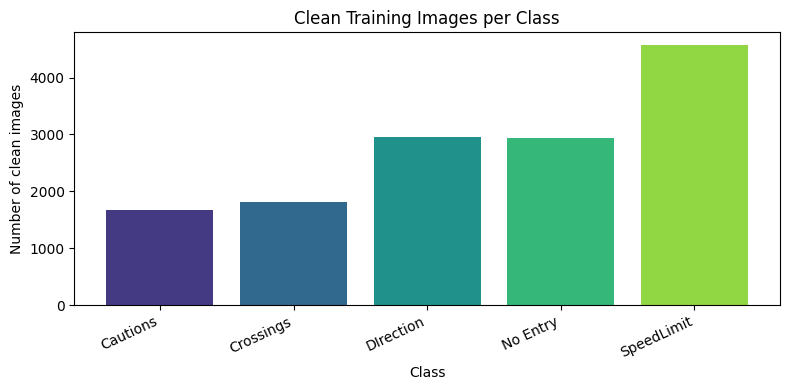

Image dimensions after corrupted files are deleted:


,width,height
count,13952.000000,13952.000000
mean,49.427609,49.481006
std,23.310246,22.704585
min,25.000000,25.000000
25%,34.000000,34.000000
50%,42.000000,42.000000
75%,56.000000,56.000000
max,226.000000,219.000000


In [7]:
# Class distribution and image-size analysis after corrupted-file cleanup
clean_distribution = all_labeled_df['class_name'].value_counts().reindex(CLASS_NAMES).rename('clean_images')

distribution_df = clean_distribution.reset_index()
distribution_df = distribution_df.rename(columns={'index': 'class_name'})
distribution_df['clean_percent_of_dataset'] = (distribution_df['clean_images'] / distribution_df['clean_images'].sum() * 100).round(2)

display(distribution_df)

plt.figure(figsize=(8, 4))
plt.bar(distribution_df['class_name'], distribution_df['clean_images'], color=sns.color_palette('viridis', len(distribution_df)))
plt.title('Clean Training Images per Class')
plt.xlabel('Class')
plt.ylabel('Number of clean images')
plt.xticks(rotation=25, ha='right')
plt.tight_layout()
plt.show()

print('Image dimensions after corrupted files are deleted:')
display(all_labeled_df[['width', 'height']].describe())

**How is the dataset split into training and validation sets? Justify your choice.**

**Answer:** Since the original Test folder is unlabeled, it cannot be used for accuracy, precision, recall, or F1-score. Therefore, the labeled training data is split into training, validation, and pseudo-test sets using stratified sampling.

- Training set: used for model learning.
- Validation set: used for tuning, early stopping, and monitoring training.
- Pseudo-test set: used for quantitative performance evaluation.
- Original Test folder: used only for qualitative prediction and demonstration.

This split is justified because it keeps evaluation fair while preserving similar class distributions across the subsets.

In [8]:
# Stratified split into training, validation, and pseudo-test sets
train_val_df, pseudo_test_df = train_test_split(
    all_labeled_df,
    test_size=PSEUDO_TEST_SIZE,
    stratify=all_labeled_df['class_name'],
    random_state=SEED
)

train_df, val_df = train_test_split(
    train_val_df,
    test_size=VALIDATION_SIZE_FROM_REMAINING,
    stratify=train_val_df['class_name'],
    random_state=SEED
)

train_df = train_df.reset_index(drop=True)
val_df = val_df.reset_index(drop=True)
pseudo_test_df = pseudo_test_df.reset_index(drop=True)

split_summary = pd.DataFrame({
    'training': train_df['class_name'].value_counts().reindex(CLASS_NAMES),
    'validation': val_df['class_name'].value_counts().reindex(CLASS_NAMES),
    'pseudo_test': pseudo_test_df['class_name'].value_counts().reindex(CLASS_NAMES)
}).fillna(0).astype(int)

print('Training set size:', len(train_df))
print('Validation set size:', len(val_df))
print('Pseudo-test set size:', len(pseudo_test_df))
display(split_summary)

Training set size: 8928
Validation set size: 2233
Pseudo-test set size: 2791


,training,validation,pseudo_test
class_name,,,
Cautions,1070,267,334
Crossings,1165,292,364
DIrection,1894,474,593
No Entry,1876,469,586
SpeedLimit,2923,731,914


**What preprocessing techniques (e.g., resizing, normalization) were applied?**

**Answer:** Images are converted to RGB, resized to a fixed shape, loaded in batches, and normalized. The CNN models trained from scratch use 128 x 128 images with pixel values rescaled to 0 to 1. The transfer-learning model uses 224 x 224 images with MobileNetV2 preprocessing.

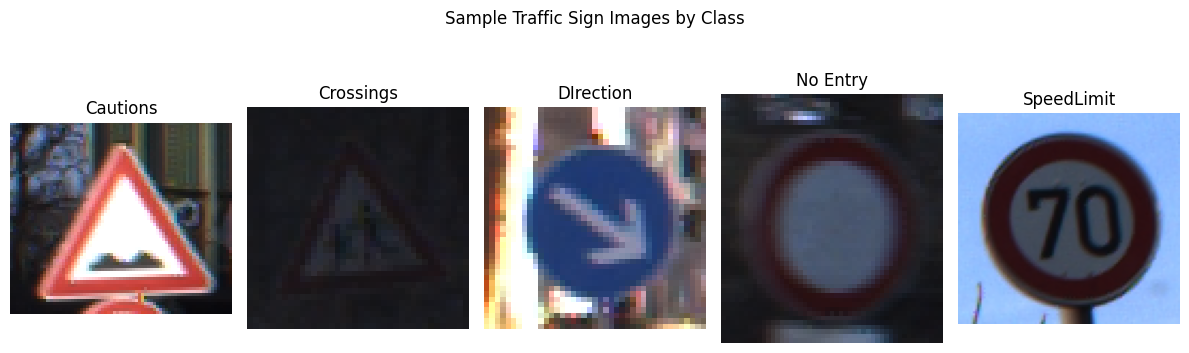

In [9]:
# Visualize one sample image from each class
sample_df = all_labeled_df.groupby('class_name', group_keys=False).sample(1, random_state=SEED)

plt.figure(figsize=(12, 4))
for i, (_, row) in enumerate(sample_df.iterrows(), start=1):
    image = Image.open(row['filepath']).convert('RGB')
    plt.subplot(1, NUM_CLASSES, i)
    plt.imshow(image)
    plt.title(row['class_name'])
    plt.axis('off')
plt.suptitle('Sample Traffic Sign Images by Class')
plt.tight_layout()
plt.show()

**What data generators, if any, were used for preprocessing and augmentation?**

**Answer:** Keras ImageDataGenerator is used to load images from dataframes. The training generator performs augmentation and normalization, while validation and pseudo-test generators only apply deterministic preprocessing. The original unlabeled Test generator is used only for prediction.

In [10]:
# Data generators for models trained from scratch

def make_scratch_generators(image_size=SCRATCH_IMG_SIZE, batch_size=BATCH_SIZE):
    train_datagen = ImageDataGenerator(
        rescale=1.0 / 255.0,
        rotation_range=18,
        width_shift_range=0.12,
        height_shift_range=0.12,
        zoom_range=0.15,
        shear_range=0.08,
        brightness_range=(0.80, 1.20),
        fill_mode='nearest'
    )
    evaluation_datagen = ImageDataGenerator(rescale=1.0 / 255.0)

    train_gen = train_datagen.flow_from_dataframe(
        train_df,
        x_col='filepath',
        y_col='class_name',
        classes=CLASS_NAMES,
        target_size=image_size,
        color_mode='rgb',
        class_mode='categorical',
        batch_size=batch_size,
        shuffle=True,
        seed=SEED
    )
    val_gen = evaluation_datagen.flow_from_dataframe(
        val_df,
        x_col='filepath',
        y_col='class_name',
        classes=CLASS_NAMES,
        target_size=image_size,
        color_mode='rgb',
        class_mode='categorical',
        batch_size=batch_size,
        shuffle=False
    )
    pseudo_test_gen = evaluation_datagen.flow_from_dataframe(
        pseudo_test_df,
        x_col='filepath',
        y_col='class_name',
        classes=CLASS_NAMES,
        target_size=image_size,
        color_mode='rgb',
        class_mode='categorical',
        batch_size=batch_size,
        shuffle=False
    )
    original_test_gen = evaluation_datagen.flow_from_dataframe(
        original_test_df,
        x_col='filepath',
        y_col=None,
        target_size=image_size,
        color_mode='rgb',
        class_mode=None,
        batch_size=batch_size,
        shuffle=False
    )
    return train_gen, val_gen, pseudo_test_gen, original_test_gen

train_gen, val_gen, pseudo_test_gen, original_test_gen = make_scratch_generators()
print('Class indices:', train_gen.class_indices)

Found 8928 validated image filenames belonging to 5 classes.
Found 2233 validated image filenames belonging to 5 classes.
Found 2791 validated image filenames belonging to 5 classes.
Found 10 validated image filenames.
Class indices: {'Cautions': 0, 'Crossings': 1, 'DIrection': 2, 'No Entry': 3, 'SpeedLimit': 4}


**If data augmentation was applied, provide visualizations of sample augmented images.**

**Answer:** Data augmentation is applied only to the training set using rotation, shifting, zooming, shearing, brightness changes, and nearest-pixel filling. The cell below visualizes augmented samples.

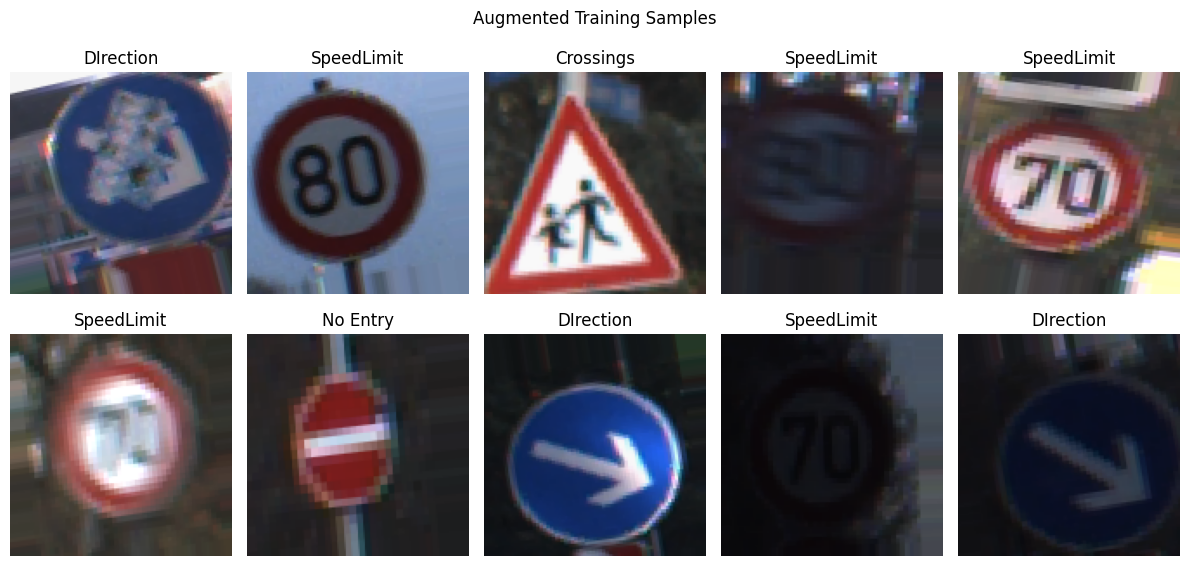

In [11]:
# Visualize augmented training samples
train_gen.reset()
augmented_images, augmented_labels = next(train_gen)
index_to_class = {index: name for name, index in train_gen.class_indices.items()}

plt.figure(figsize=(12, 6))
for i in range(min(10, len(augmented_images))):
    plt.subplot(2, 5, i + 1)
    plt.imshow(augmented_images[i])
    plt.title(index_to_class[int(np.argmax(augmented_labels[i]))])
    plt.axis('off')
plt.suptitle('Augmented Training Samples')
plt.tight_layout()
plt.show()

**Additional cleaning and imbalance handling.**

**Answer:** Invalid images are skipped without deleting them from disk. Class weights are calculated from the training split to reduce the effect of class imbalance during model training.

In [12]:
# Class weights reduce bias toward the majority class
weights = compute_class_weight(
    class_weight='balanced',
    classes=np.array(CLASS_NAMES),
    y=train_df['class_name'].values
)
class_weight_by_name = dict(zip(CLASS_NAMES, weights))
class_weight = {train_gen.class_indices[name]: float(weight) for name, weight in class_weight_by_name.items()}

print('Class weights:')
for class_name, weight in class_weight_by_name.items():
    print(f'{class_name}: {weight:.3f}')

Class weights:
Cautions: 1.669
Crossings: 1.533
DIrection: 0.943
No Entry: 0.952
SpeedLimit: 0.611


## Supporting Training and Evaluation Functions

**Answer:** The helper functions below train models, plot loss and accuracy curves, evaluate on the pseudo-test set, generate classification reports, create confusion matrices, and store experiment results.

In [13]:
EXPERIMENT_RESULTS = []
TRAINING_HISTORIES = {}


def make_callbacks(model_name):
    return [
        keras.callbacks.EarlyStopping(monitor='val_loss', patience=3, restore_best_weights=True, verbose=1),
        keras.callbacks.ReduceLROnPlateau(monitor='val_loss', factor=0.3, patience=2, min_lr=1e-6, verbose=1)
    ]


def compile_classifier(model, optimizer_name='adam', learning_rate=None):
    if optimizer_name.lower() == 'adam':
        optimizer = keras.optimizers.Adam(learning_rate=learning_rate or 1e-3)
    elif optimizer_name.lower() == 'sgd':
        optimizer = keras.optimizers.SGD(learning_rate=learning_rate or 0.01, momentum=0.9)
    else:
        raise ValueError('Use optimizer_name adam or sgd.')

    model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
    return model


def fit_model(model, train_generator, validation_generator, epochs, model_name, use_class_weight=True):
    start_time = time.perf_counter()
    history = model.fit(
        train_generator,
        validation_data=validation_generator,
        epochs=epochs,
        callbacks=make_callbacks(model_name),
        class_weight=class_weight if use_class_weight else None,
        verbose=1
    )
    training_time = time.perf_counter() - start_time
    TRAINING_HISTORIES[model_name] = history
    print(f'{model_name} training time: {training_time:.2f} seconds ({training_time / 60:.2f} minutes)')
    return history, training_time


def plot_history(history, title):
    history_df = pd.DataFrame(history.history)
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    axes[0].plot(history_df.index + 1, history_df['loss'], label='Training loss')
    axes[0].plot(history_df.index + 1, history_df['val_loss'], label='Validation loss')
    axes[0].set_title(f'{title}: Loss')
    axes[0].set_xlabel('Epoch')
    axes[0].set_ylabel('Loss')
    axes[0].legend()

    axes[1].plot(history_df.index + 1, history_df['accuracy'], label='Training accuracy')
    axes[1].plot(history_df.index + 1, history_df['val_accuracy'], label='Validation accuracy')
    axes[1].set_title(f'{title}: Accuracy')
    axes[1].set_xlabel('Epoch')
    axes[1].set_ylabel('Accuracy')
    axes[1].legend()
    plt.tight_layout()
    plt.show()
    display(history_df.tail())


def upsert_result(row):
    global EXPERIMENT_RESULTS
    EXPERIMENT_RESULTS = [item for item in EXPERIMENT_RESULTS if item['model'] != row['model']]
    EXPERIMENT_RESULTS.append(row)


def evaluate_on_pseudo_test(model, generator, model_name, training_time_seconds=None):
    generator.reset()
    loss, accuracy = model.evaluate(generator, verbose=0)

    generator.reset()
    probabilities = model.predict(generator, verbose=1)
    y_pred = np.argmax(probabilities, axis=1)
    y_true = generator.classes
    class_names = list(generator.class_indices.keys())

    precision, recall, f1, _ = precision_recall_fscore_support(y_true, y_pred, average='weighted', zero_division=0)
    result = {
        'model': model_name,
        'pseudo_test_loss': float(loss),
        'pseudo_test_accuracy': float(accuracy),
        'weighted_precision': float(precision),
        'weighted_recall': float(recall),
        'weighted_f1': float(f1),
        'training_time_seconds': float(training_time_seconds) if training_time_seconds is not None else np.nan,
        'training_time_minutes': float(training_time_seconds / 60) if training_time_seconds is not None else np.nan
    }
    upsert_result(result)

    display(pd.DataFrame([result]))
    print(classification_report(y_true, y_pred, target_names=class_names, zero_division=0))

    confusion = confusion_matrix(y_true, y_pred)
    fig, ax = plt.subplots(figsize=(7, 6))
    ConfusionMatrixDisplay(confusion_matrix=confusion, display_labels=class_names).plot(ax=ax, cmap='Blues', xticks_rotation=30)
    plt.title(f'{model_name}: Pseudo-Test Confusion Matrix')
    plt.tight_layout()
    plt.show()
    return result


def plot_sample_predictions(model, generator, title, n=10):
    generator.reset()
    images, labels = next(generator)
    probabilities = model.predict(images, verbose=0)
    predictions = np.argmax(probabilities, axis=1)
    true_labels = np.argmax(labels, axis=1)
    class_names = list(generator.class_indices.keys())

    n = min(n, len(images))
    plt.figure(figsize=(14, 6))
    for i in range(n):
        plt.subplot(2, math.ceil(n / 2), i + 1)
        plt.imshow(images[i])
        title_color = 'green' if predictions[i] == true_labels[i] else 'red'
        plt.title(f'Pred: {class_names[predictions[i]]}\nTrue: {class_names[true_labels[i]]}', color=title_color)
        plt.axis('off')
    plt.suptitle(title)
    plt.tight_layout()
    plt.show()


def comparison_table():
    if not EXPERIMENT_RESULTS:
        return pd.DataFrame()
    return pd.DataFrame(EXPERIMENT_RESULTS).sort_values('pseudo_test_accuracy', ascending=False).reset_index(drop=True)

## 2.5.2 Design, Train, and Evaluate a Baseline Model:

### 1. Model Architecture:

* Build a baseline CNN model with the following structure:
* Three Convolutional layers, each followed by pooling layers.
* Three fully connected layers (FCN)
* An output layer suitable for classification.
* Include Kernel Sizes, Number of Filters, and Activation Functions.
* Provide and Interpret the model summary.

**Answer:** The baseline model uses three convolutional layers with 3 x 3 kernels and ReLU activation. Each convolutional layer is followed by max pooling. The classifier contains three dense layers followed by a five-class softmax output layer.

In [14]:
def build_baseline_cnn(input_shape=(*SCRATCH_IMG_SIZE, 3), num_classes=NUM_CLASSES, optimizer_name='adam'):
    model = keras.Sequential([
        layers.Input(shape=input_shape),
        layers.Conv2D(32, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(64, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Conv2D(128, (3, 3), activation='relu', padding='same'),
        layers.MaxPooling2D((2, 2)),
        layers.Flatten(),
        layers.Dense(256, activation='relu'),
        layers.Dense(128, activation='relu'),
        layers.Dense(64, activation='relu'),
        layers.Dense(num_classes, activation='softmax')
    ], name='baseline_cnn')
    return compile_classifier(model, optimizer_name=optimizer_name)

baseline_model = build_baseline_cnn()
baseline_model.summary()

Model: "baseline_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 128, 128, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 64, 64, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 32, 32, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 16, 16, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 32768)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 256)            │     8,388,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 5)              │           325 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,523,589 (32.51 MB)

 Trainable params: 8,523,589 (32.51 MB)

 Non-trainable params: 0 (0.00 B)

### 2. Model Training:

* Train the baseline model for an appropriate number of epochs.
* Plot the training vs validation loss curves over epochs.
* Note: We recommend using Google Colab with GPU or TPU acceleration for training.

**Answer:** The baseline model is trained with Adam, categorical cross-entropy loss, early stopping, learning-rate reduction, and class weights. The training and validation curves are plotted after training.

### 3. Model Evaluation:

* Evaluate the model using appropriate metrics (e.g. accuracy, precision, recall and F-1 score).
* Perform inference on sample images and plot the result.
* Discuss key observations about model performance.

**Answer:** The baseline model is evaluated on the pseudo-test set using accuracy, weighted precision, weighted recall, weighted F1-score, a classification report, and a confusion matrix. Sample pseudo-test predictions are also plotted.

Epoch 1/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 86s 284ms/step - accuracy: 0.7282 - loss: 0.6548 - val_accuracy: 0.8639 - val_loss: 0.2718 - learning_rate: 0.0010
Epoch 2/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 78s 278ms/step - accuracy: 0.8535 - loss: 0.3759 - val_accuracy: 0.9212 - val_loss: 0.1803 - learning_rate: 0.0010
Epoch 3/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 77s 275ms/step - accuracy: 0.9106 - loss: 0.2657 - val_accuracy: 0.9243 - val_loss: 0.1877 - learning_rate: 0.0010
Epoch 4/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 76s 271ms/step - accuracy: 0.9446 - loss: 0.1913 - val_accuracy: 0.9575 - val_loss: 0.0983 - learning_rate: 0.0010
Epoch 5/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 77s 276ms/step - accuracy: 0.9607 - loss: 0.1369 - val_accuracy: 0.9798 - val_loss: 0.0621 - learning_rate: 0.0010
Epoch 6/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 77s 275ms/step - accuracy: 0.9693 - loss: 0.1033 - val_accuracy: 0.9875 - val_loss: 0.0418 - learning_rate: 0.0010
Epoch 7/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 80s 287ms/step - accuracy: 0.9

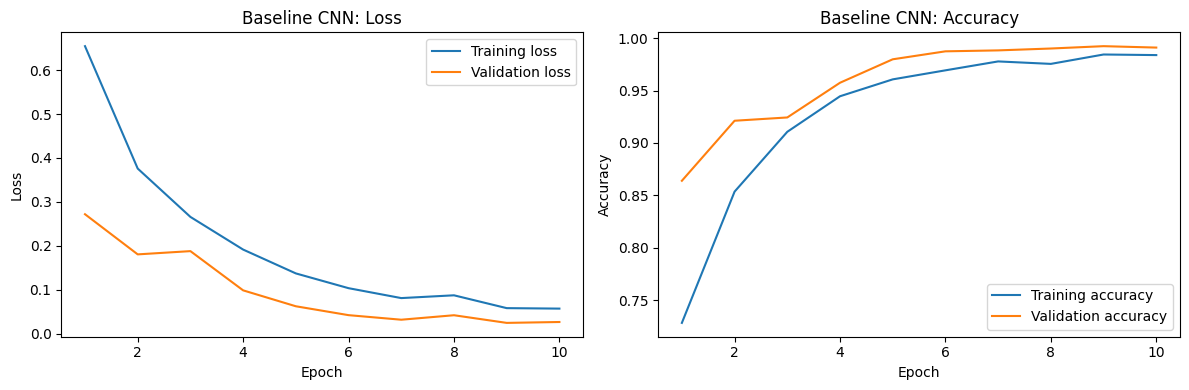

,accuracy,loss,val_accuracy,val_loss,learning_rate
5,0.969310,0.103280,0.987461,0.041813,0.001
6,0.977823,0.080702,0.988356,0.031422,0.001
7,0.975470,0.087042,0.990148,0.041629,0.001
8,0.984431,0.057810,0.992387,0.024194,0.001
9,0.983871,0.056727,0.991043,0.026200,0.001


88/88 ━━━━━━━━━━━━━━━━━━━━ 10s 104ms/step


,model,pseudo_test_loss,pseudo_test_accuracy,weighted_precision,weighted_recall,weighted_f1,training_time_seconds,training_time_minutes
0,Baseline CNN,0.014711,0.996059,0.996098,0.996059,0.99606,780.93927,13.015655


              precision    recall  f1-score   support

    Cautions       0.98      0.99      0.99       334
   Crossings       0.99      0.98      0.99       364
   DIrection       1.00      1.00      1.00       593
    No Entry       1.00      1.00      1.00       586
  SpeedLimit       1.00      1.00      1.00       914

    accuracy                           1.00      2791
   macro avg       0.99      0.99      0.99      2791
weighted avg       1.00      1.00      1.00      2791



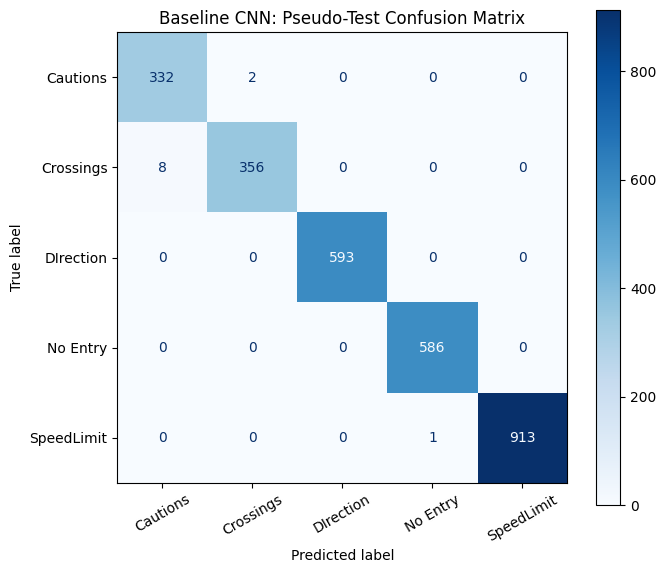

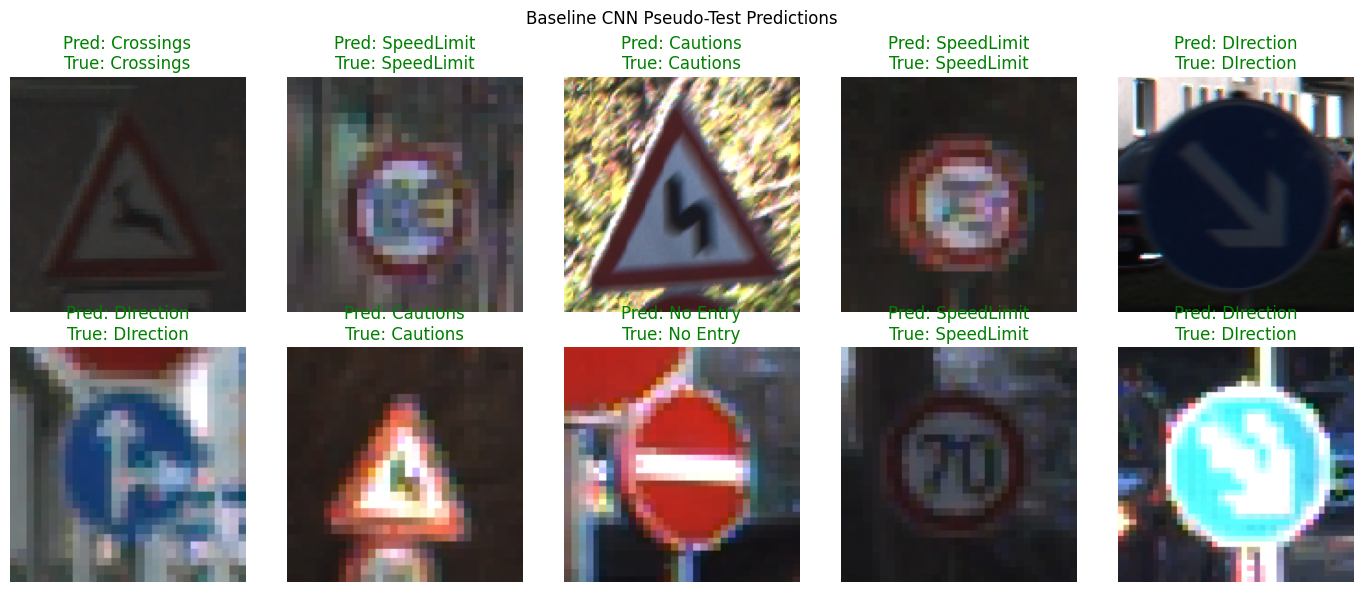

In [15]:
baseline_history, baseline_time = fit_model(
    baseline_model,
    train_gen,
    val_gen,
    epochs=BASELINE_EPOCHS,
    model_name='Baseline CNN',
    use_class_weight=True
)
plot_history(baseline_history, 'Baseline CNN')
baseline_metrics = evaluate_on_pseudo_test(baseline_model, pseudo_test_gen, 'Baseline CNN', baseline_time)
plot_sample_predictions(baseline_model, pseudo_test_gen, 'Baseline CNN Pseudo-Test Predictions')

## 2.5.3 Deeper Architecture with Regularization Layer:

### 1. Model Architecture:

* Extend the baseline model by modifying the number of filters and layers to build deeper architecture at least double the layer in comparison to baseline model.
* Extend the layers introducing the following regularization techniques.
* Print and analyze the new model summary.

**Answer:** The deeper model uses six convolutional layers arranged in three convolution blocks, which doubles the convolutional depth of the baseline. Batch normalization, dropout, and L2 regularization are added to reduce overfitting and improve generalization.

### 2. Model Training:

* Train the deeper model for an appropriate number of epochs.
* Compare its training time and loss curves against the baseline model.

**Answer:** The deeper model is trained using the same training and validation splits as the baseline. Training time and learning curves are recorded for comparison.

### 3. Model Evaluation:

* Evaluate the deeper model on the same performance metrics as the baseline model.
* Discuss improvements (or lack thereof) compared to the baseline model.

**Answer:** The deeper model is evaluated on the same pseudo-test set using the same metrics as the baseline, allowing a fair comparison.

In [19]:
def conv_block(x, filters, use_batch_norm=True, use_dropout=True,
               dropout_rate=0.20, l2_strength=1e-4):

    x = layers.Conv2D(
        filters,
        (3, 3),
        padding='same',
        kernel_regularizer=regularizers.l2(l2_strength),
        use_bias=not use_batch_norm
    )(x)

    if use_batch_norm:
        x = layers.BatchNormalization()(x)

    x = layers.Activation('relu')(x)

    x = layers.Conv2D(
        filters,
        (3, 3),
        padding='same',
        kernel_regularizer=regularizers.l2(l2_strength),
        use_bias=not use_batch_norm
    )(x)

    if use_batch_norm:
        x = layers.BatchNormalization()(x)

    x = layers.Activation('relu')(x)

    x = layers.MaxPooling2D((2, 2))(x)

    if use_dropout:
        x = layers.Dropout(dropout_rate)(x)

    return x


def build_deeper_cnn(input_shape=(*SCRATCH_IMG_SIZE, 3),
                     num_classes=NUM_CLASSES,
                     optimizer_name='adam',
                     learning_rate=None,
                     use_batch_norm=True,
                     use_dropout=True,
                     name='deeper_regularized_cnn'):

    inputs = keras.Input(shape=input_shape)

    # Block 1
    x = conv_block(
        inputs,
        16,
        use_batch_norm=use_batch_norm,
        use_dropout=use_dropout,
        dropout_rate=0.10
    )

    # Block 2
    x = conv_block(
        x,
        32,
        use_batch_norm=use_batch_norm,
        use_dropout=use_dropout,
        dropout_rate=0.15
    )

    # Block 3
    x = conv_block(
        x,
        64,
        use_batch_norm=use_batch_norm,
        use_dropout=use_dropout,
        dropout_rate=0.20
    )

    # Block 4
    x = conv_block(
        x,
        128,
        use_batch_norm=use_batch_norm,
        use_dropout=use_dropout,
        dropout_rate=0.25
    )

    # Replace Flatten with GAP
    x = layers.GlobalAveragePooling2D()(x)

    # Dense Layer 1
    x = layers.Dense(
        128,
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    if use_batch_norm:
        x = layers.BatchNormalization()(x)

    x = layers.Activation('relu')(x)

    if use_dropout:
        x = layers.Dropout(0.40)(x)

    # Dense Layer 2
    x = layers.Dense(
        64,
        kernel_regularizer=regularizers.l2(1e-4)
    )(x)

    if use_batch_norm:
        x = layers.BatchNormalization()(x)

    x = layers.Activation('relu')(x)

    if use_dropout:
        x = layers.Dropout(0.30)(x)

    # Output Layer
    outputs = layers.Dense(
        num_classes,
        activation='softmax'
    )(x)

    model = keras.Model(inputs, outputs, name=name)

    return compile_classifier(
        model,
        optimizer_name=optimizer_name,
        learning_rate=learning_rate
    )


deeper_model = build_deeper_cnn()
deeper_model.summary()

Model: "deeper_regularized_cnn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_2 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_9 (Conv2D)               │ (None, 128, 128, 16)   │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_6           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_6 (Activation)       │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_10 (Conv2D)              │ (None, 128, 128, 16)   │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_7           │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_7 (Activation)       │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_6 (MaxPooling2D)  │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_11 (Conv2D)              │ (None, 64, 64, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_8           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_8 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_12 (Conv2D)              │ (None, 64, 64, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_9           │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_9 (Activation)       │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_7 (MaxPooling2D)  │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_13 (Conv2D)              │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_10          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_10 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_14 (Conv2D)              │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_11          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │             

 Total params: 320,821 (1.22 MB)

 Trainable params: 319,477 (1.22 MB)

 Non-trainable params: 1,344 (5.25 KB)

In [20]:
deeper_history, deeper_time = fit_model(
    deeper_model,
    train_gen,
    val_gen,
    epochs=DEEP_EPOCHS,
    model_name='Deeper Regularized CNN',
    use_class_weight=True
)

Epoch 1/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 106s 315ms/step - accuracy: 0.4787 - loss: 1.3033 - val_accuracy: 0.4241 - val_loss: 1.5145 - learning_rate: 0.0010
Epoch 2/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 90s 322ms/step - accuracy: 0.6401 - loss: 0.9502 - val_accuracy: 0.6574 - val_loss: 0.8062 - learning_rate: 0.0010
Epoch 3/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 82s 294ms/step - accuracy: 0.7675 - loss: 0.6702 - val_accuracy: 0.7250 - val_loss: 0.7327 - learning_rate: 0.0010
Epoch 4/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 78s 281ms/step - accuracy: 0.8459 - loss: 0.5083 - val_accuracy: 0.8142 - val_loss: 0.4700 - learning_rate: 0.0010
Epoch 5/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 78s 279ms/step - accuracy: 0.9048 - loss: 0.3775 - val_accuracy: 0.7564 - val_loss: 0.7993 - learning_rate: 0.0010
Epoch 6/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 0s 272ms/step - accuracy: 0.9359 - loss: 0.2929
Epoch 6: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
279/279 ━━━━━━━━━━━━━━━━━━━━ 83s 298ms/step - accuracy: 0.94

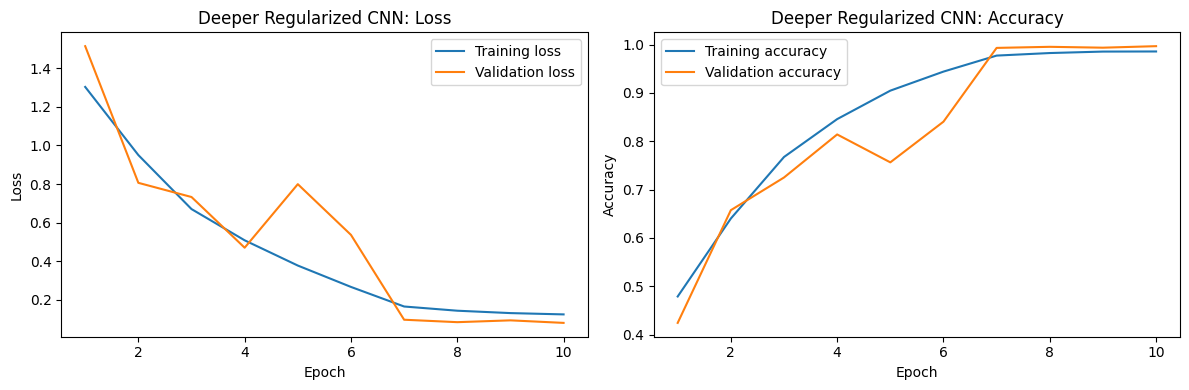

,accuracy,loss,val_accuracy,val_loss,learning_rate
5,0.944220,0.266736,0.840573,0.536490,0.0010
6,0.977375,0.165276,0.993283,0.096739,0.0003
7,0.982639,0.143475,0.995522,0.084094,0.0003
8,0.985663,0.131113,0.993730,0.093481,0.0003
9,0.985887,0.124356,0.996865,0.080373,0.0003


88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step


,model,pseudo_test_loss,pseudo_test_accuracy,weighted_precision,weighted_recall,weighted_f1,training_time_seconds,training_time_minutes
0,Deeper Regularized CNN,0.077788,0.999283,0.999288,0.999283,0.999283,848.78799,14.146467


              precision    recall  f1-score   support

    Cautions       0.99      1.00      1.00       334
   Crossings       1.00      0.99      1.00       364
   DIrection       1.00      1.00      1.00       593
    No Entry       1.00      1.00      1.00       586
  SpeedLimit       1.00      1.00      1.00       914

    accuracy                           1.00      2791
   macro avg       1.00      1.00      1.00      2791
weighted avg       1.00      1.00      1.00      2791



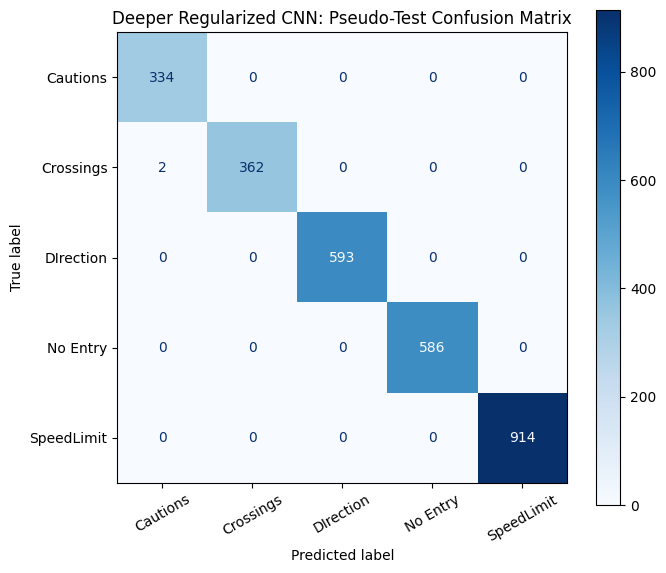

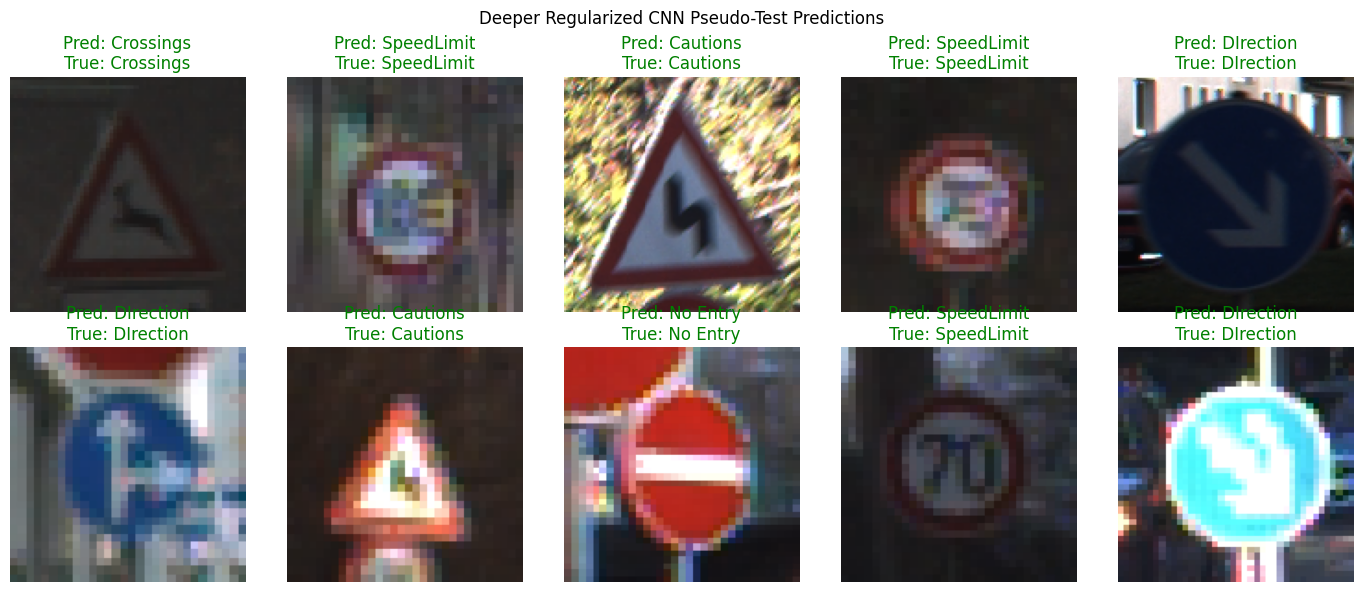

In [21]:
plot_history(deeper_history, 'Deeper Regularized CNN')
deeper_metrics = evaluate_on_pseudo_test(deeper_model, pseudo_test_gen, 'Deeper Regularized CNN', deeper_time)
plot_sample_predictions(deeper_model, pseudo_test_gen, 'Deeper Regularized CNN Pseudo-Test Predictions')

## 2.5.4 Experimentation and Comparative Analysis:

### 1. Baseline vs. Deeper Model Performance:

* Compare classification accuracy, loss, and evaluation metrics.
* Discuss whether adding more layers and filters improved performance.

**Answer:** The comparison table and plot show whether the deeper model improves pseudo-test accuracy, loss, precision, recall, and F1-score compared with the baseline model.

,model,pseudo_test_loss,pseudo_test_accuracy,weighted_precision,weighted_recall,weighted_f1,training_time_seconds,training_time_minutes
0,Deeper Regularized CNN,0.077788,0.999283,0.999288,0.999283,0.999283,848.78799,14.146467
1,Baseline CNN,0.014711,0.996059,0.996098,0.996059,0.996060,780.93927,13.015655


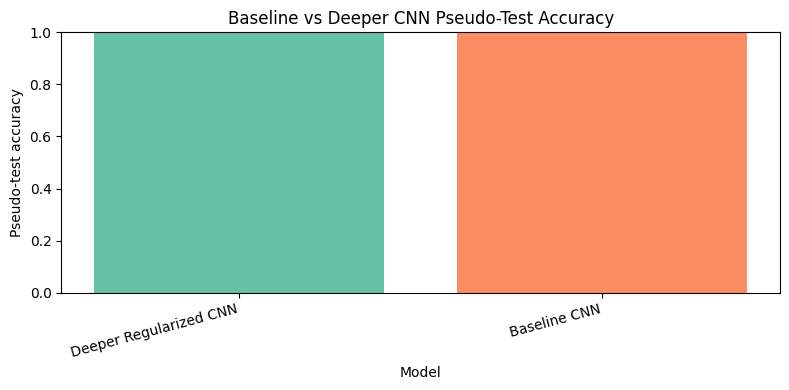

In [22]:
# Baseline vs deeper architecture
results_df = comparison_table()
display(results_df)

plt.figure(figsize=(8, 4))
plot_df = results_df[results_df['model'].isin(['Baseline CNN', 'Deeper Regularized CNN'])]
if plot_df.empty:
    print('Run the baseline and deeper model cells before plotting this comparison.')
else:
    plt.bar(plot_df['model'], plot_df['pseudo_test_accuracy'], color=sns.color_palette('Set2', len(plot_df)))
    plt.title('Baseline vs Deeper CNN Pseudo-Test Accuracy')
    plt.xlabel('Model')
    plt.ylabel('Pseudo-test accuracy')
    plt.ylim(0, 1)
    plt.xticks(rotation=15, ha='right')
    plt.tight_layout()
    plt.show()

### 2. Computational Efficiency:

* Compare training time and computational cost of the two models.
* Discuss the trade - offs between model complexity and efficiency.

**Answer:** Training time is recorded for each model. A deeper model is computationally more expensive, so its extra cost should be justified only if it improves pseudo-test performance.

### 3. Optimizer Analysis: SGD vs Adam:

* Train the deeper model with SGD and then Adam.
* Compare the impact of these optimizers on convergence speed and final performance.

**Answer:** The deeper architecture is trained separately with SGD and Adam. Their training curves, training time, and pseudo-test metrics are compared.

In [23]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=5,
    restore_best_weights=True
)

In [33]:
from tensorflow.keras.optimizers import SGD

deeper_model.compile(
    optimizer=SGD(
        learning_rate=0.01,
        momentum=0.9
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_sgd = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 98s 298ms/step - accuracy: 0.9556 - loss: 0.2095 - val_accuracy: 0.9637 - val_loss: 0.1637
Epoch 2/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 84s 300ms/step - accuracy: 0.9773 - loss: 0.1426 - val_accuracy: 0.9897 - val_loss: 0.1040
Epoch 3/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 80s 286ms/step - accuracy: 0.9851 - loss: 0.1187 - val_accuracy: 0.9951 - val_loss: 0.0866
Epoch 4/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 87s 312ms/step - accuracy: 0.9869 - loss: 0.1136 - val_accuracy: 0.9798 - val_loss: 0.1245
Epoch 5/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 79s 285ms/step - accuracy: 0.9876 - loss: 0.1113 - val_accuracy: 0.9951 - val_loss: 0.0825
Epoch 6/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 78s 280ms/step - accuracy: 0.9914 - loss: 0.1019 - val_accuracy: 0.9982 - val_loss: 0.0761
Epoch 7/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 84s 302ms/step - accuracy: 0.9882 - loss: 0.1045 - val_accuracy: 0.9951 - val_loss: 0.0872
Epoch 8/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 82s 295ms/step - accuracy: 0.9887 - loss: 0

88/88 ━━━━━━━━━━━━━━━━━━━━ 12s 116ms/step
88/88 ━━━━━━━━━━━━━━━━━━━━ 9s 97ms/step


,model,pseudo_test_loss,pseudo_test_accuracy,weighted_precision,weighted_recall,weighted_f1,training_time_seconds,training_time_minutes
0,Deeper CNN - SGD,0.072699,1.0,1.0,1.0,1.0,11.929857,0.198831


              precision    recall  f1-score   support

    Cautions       1.00      1.00      1.00       334
   Crossings       1.00      1.00      1.00       364
   DIrection       1.00      1.00      1.00       593
    No Entry       1.00      1.00      1.00       586
  SpeedLimit       1.00      1.00      1.00       914

    accuracy                           1.00      2791
   macro avg       1.00      1.00      1.00      2791
weighted avg       1.00      1.00      1.00      2791



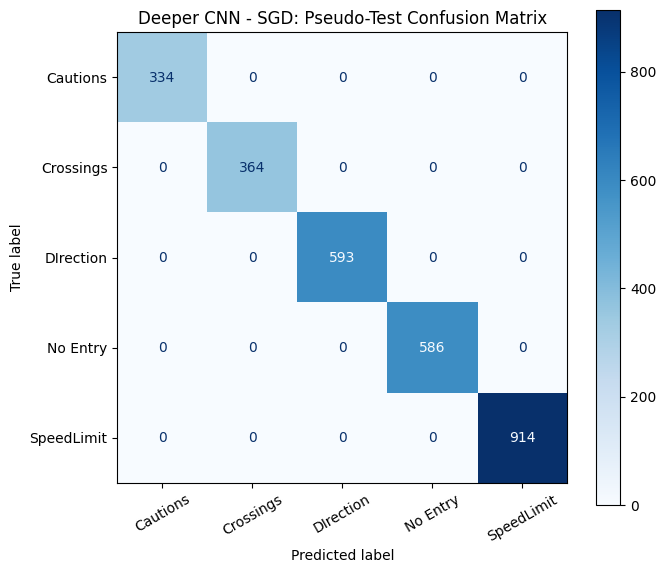

In [38]:
import time

start = time.time()
# run prediction once to measure time
_ = deeper_model.predict(pseudo_test_gen)
sgd_test_time = time.time() - start

sgd_metrics = evaluate_on_pseudo_test(
    deeper_model,
    pseudo_test_gen,
    'Deeper CNN - SGD',
    sgd_test_time
)

In [39]:
from tensorflow.keras.optimizers import Adam

deeper_model.compile(
    optimizer=Adam(
        learning_rate=0.001
    ),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_adam = deeper_model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=10,
    callbacks=[early_stop]
)

Epoch 1/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 109s 335ms/step - accuracy: 0.9778 - loss: 0.1412 - val_accuracy: 0.9951 - val_loss: 0.0899
Epoch 2/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 82s 293ms/step - accuracy: 0.9786 - loss: 0.1418 - val_accuracy: 0.9987 - val_loss: 0.0816
Epoch 3/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 80s 287ms/step - accuracy: 0.9832 - loss: 0.1303 - val_accuracy: 0.7004 - val_loss: 1.5989
Epoch 4/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 80s 288ms/step - accuracy: 0.9859 - loss: 0.1244 - val_accuracy: 0.9919 - val_loss: 0.1026
Epoch 5/10
279/279 ━━━━━━━━━━━━━━━━━━━━ 80s 286ms/step - accuracy: 0.9885 - loss: 0.1111 - val_accuracy: 0.9969 - val_loss: 0.0844


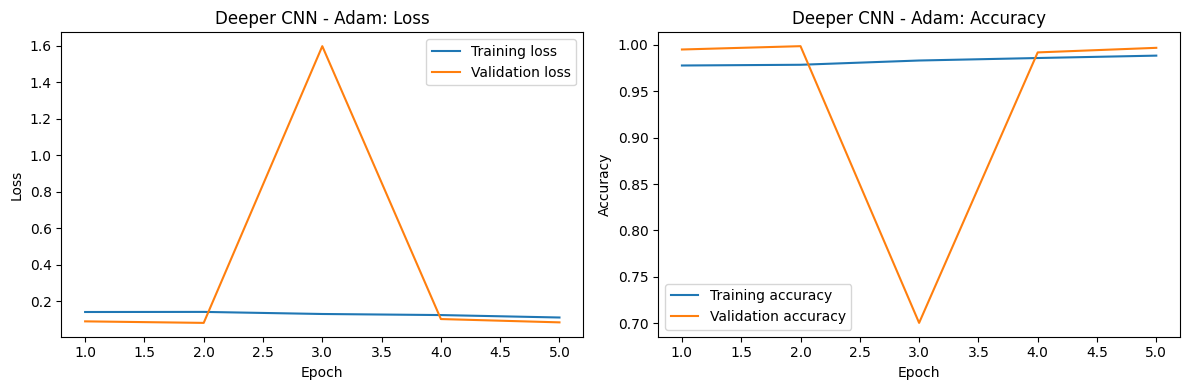

,accuracy,loss,val_accuracy,val_loss
0,0.977823,0.141229,0.995074,0.089921
1,0.978607,0.141817,0.998657,0.081550
2,0.983199,0.130318,0.700403,1.598859
3,0.985887,0.124450,0.991939,0.102586
4,0.988463,0.111060,0.996865,0.084414


88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 114ms/step


,model,pseudo_test_loss,pseudo_test_accuracy,weighted_precision,weighted_recall,weighted_f1,training_time_seconds,training_time_minutes
0,Deeper CNN - Adam,0.086449,0.994267,0.994367,0.994267,0.994289,NaN,NaN


              precision    recall  f1-score   support

    Cautions       1.00      0.99      1.00       334
   Crossings       0.97      1.00      0.98       364
   DIrection       1.00      0.99      1.00       593
    No Entry       1.00      0.99      0.99       586
  SpeedLimit       1.00      0.99      1.00       914

    accuracy                           0.99      2791
   macro avg       0.99      0.99      0.99      2791
weighted avg       0.99      0.99      0.99      2791



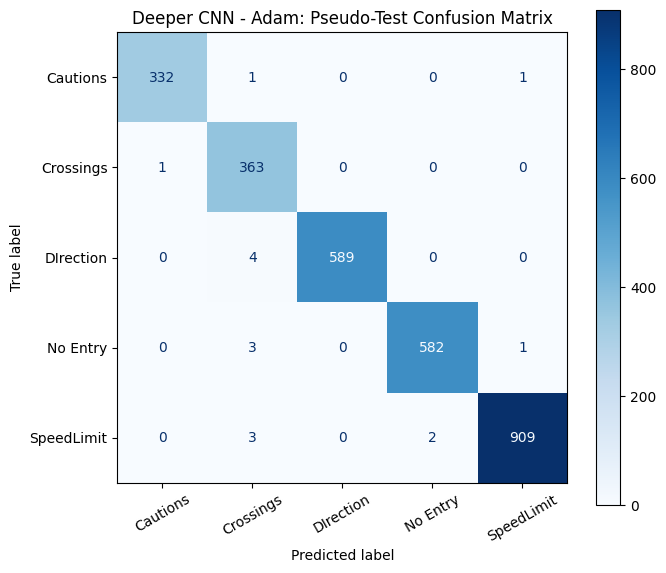

In [41]:
plot_history(history_adam, 'Deeper CNN - Adam')

adam_metrics = evaluate_on_pseudo_test(
    deeper_model,
    pseudo_test_gen,
    'Deeper CNN - Adam'
)

### 4. Ablation Study:

* Remove one component (e.g., dropout or batch normalization).
* Analyze how performance changes.

**Answer:** Dropout is removed from the deeper CNN while keeping the rest of the architecture similar. The result shows whether dropout helped reduce overfitting and improve generalization.

Model: "deeper_cnn_no_dropout"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_8 (InputLayer)      │ (None, 128, 128, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_57 (Conv2D)              │ (None, 128, 128, 16)   │           432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_66          │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_66 (Activation)      │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_58 (Conv2D)              │ (None, 128, 128, 16)   │         2,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_67          │ (None, 128, 128, 16)   │            64 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_67 (Activation)      │ (None, 128, 128, 16)   │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_30 (MaxPooling2D) │ (None, 64, 64, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_59 (Conv2D)              │ (None, 64, 64, 32)     │         4,608 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_68          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_68 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_60 (Conv2D)              │ (None, 64, 64, 32)     │         9,216 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_69          │ (None, 64, 64, 32)     │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_69 (Activation)      │ (None, 64, 64, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_31 (MaxPooling2D) │ (None, 32, 32, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_61 (Conv2D)              │ (None, 32, 32, 64)     │        18,432 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_70          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_70 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_62 (Conv2D)              │ (None, 32, 32, 64)     │        36,864 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_71          │ (None, 32, 32, 64)     │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_71 (Activation)      │ (None, 32, 32, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_32 (MaxPooling2D) │ (None, 16, 16, 64)     │             

 Total params: 320,821 (1.22 MB)

 Trainable params: 319,477 (1.22 MB)

 Non-trainable params: 1,344 (5.25 KB)

Epoch 1/8
279/279 ━━━━━━━━━━━━━━━━━━━━ 98s 303ms/step - accuracy: 0.6293 - loss: 1.0152 - val_accuracy: 0.3641 - val_loss: 1.5490 - learning_rate: 0.0010
Epoch 2/8
279/279 ━━━━━━━━━━━━━━━━━━━━ 79s 285ms/step - accuracy: 0.8505 - loss: 0.5144 - val_accuracy: 0.8755 - val_loss: 0.3980 - learning_rate: 0.0010
Epoch 3/8
279/279 ━━━━━━━━━━━━━━━━━━━━ 78s 279ms/step - accuracy: 0.9458 - loss: 0.2483 - val_accuracy: 0.9521 - val_loss: 0.2110 - learning_rate: 0.0010
Epoch 4/8
279/279 ━━━━━━━━━━━━━━━━━━━━ 79s 283ms/step - accuracy: 0.9651 - loss: 0.1901 - val_accuracy: 0.8616 - val_loss: 0.5832 - learning_rate: 0.0010
Epoch 5/8
279/279 ━━━━━━━━━━━━━━━━━━━━ 0s 260ms/step - accuracy: 0.9780 - loss: 0.1511
Epoch 5: ReduceLROnPlateau reducing learning rate to 0.0003000000142492354.
279/279 ━━━━━━━━━━━━━━━━━━━━ 79s 284ms/step - accuracy: 0.9779 - loss: 0.1502 - val_accuracy: 0.9378 - val_loss: 0.2360 - learning_rate: 0.0010
Epoch 6/8
279/279 ━━━━━━━━━━━━━━━━━━━━ 80s 285ms/step - accuracy: 0.9938 - lo

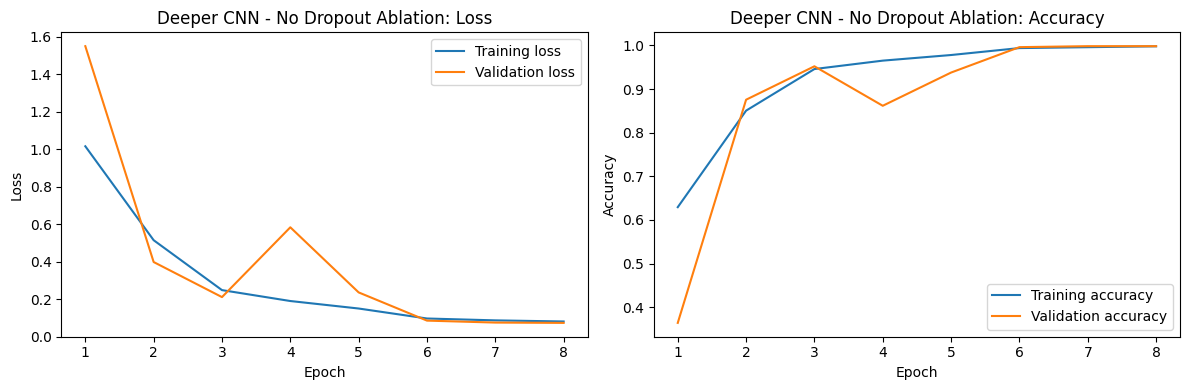

,accuracy,loss,val_accuracy,val_loss,learning_rate
3,0.965054,0.190127,0.861621,0.583183,0.0010
4,0.977935,0.150166,0.937752,0.236027,0.0010
5,0.993840,0.096918,0.995970,0.085632,0.0003
6,0.995856,0.086961,0.998209,0.075233,0.0003
7,0.997872,0.081033,0.998209,0.073551,0.0003


88/88 ━━━━━━━━━━━━━━━━━━━━ 11s 111ms/step


,model,pseudo_test_loss,pseudo_test_accuracy,weighted_precision,weighted_recall,weighted_f1,training_time_seconds,training_time_minutes
0,Deeper CNN - No Dropout Ablation,0.071894,0.999642,0.999643,0.999642,0.999642,651.217472,10.853625


              precision    recall  f1-score   support

    Cautions       1.00      1.00      1.00       334
   Crossings       1.00      1.00      1.00       364
   DIrection       1.00      1.00      1.00       593
    No Entry       1.00      1.00      1.00       586
  SpeedLimit       1.00      1.00      1.00       914

    accuracy                           1.00      2791
   macro avg       1.00      1.00      1.00      2791
weighted avg       1.00      1.00      1.00      2791



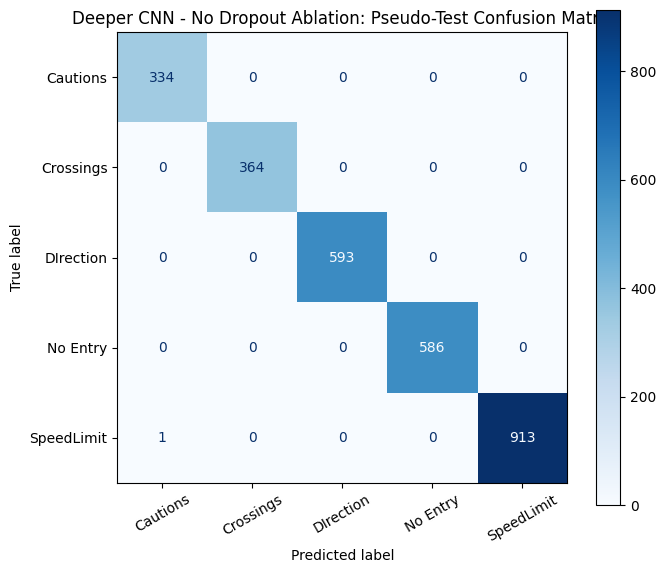

In [45]:
ablation_model = build_deeper_cnn(use_batch_norm=True, use_dropout=False, optimizer_name='adam', name='deeper_cnn_no_dropout')
ablation_model.summary()

ablation_history, ablation_time = fit_model(
    ablation_model,
    train_gen,
    val_gen,
    epochs=ABLATION_EPOCHS,
    model_name='Deeper CNN - No Dropout Ablation',
    use_class_weight=True
)
plot_history(ablation_history, 'Deeper CNN - No Dropout Ablation')
ablation_metrics = evaluate_on_pseudo_test(ablation_model, pseudo_test_gen, 'Deeper CNN - No Dropout Ablation', ablation_time)

### 5. Challenges and Observations:

* Discuss any difficulties faced, such as overfitting and underfitting.
* Report the total training time for deeper architecture.
* Mention if hardware acceleration (e.g. Google Colab, with GPU/TPU was used.

**Answer:** The main expected challenges are class imbalance, corrupted image files, possible overfitting, optimizer sensitivity, and training time. The final discussion should use the actual training curves, pseudo-test metrics, and recorded training times produced after running the notebook.

In [46]:
# Save scratch-model experiment results
scratch_results_df = comparison_table()
display(scratch_results_df)

scratch_results_path = OUTPUT_DIR / 'scratch_experiment_results.csv'
scratch_results_df.to_csv(scratch_results_path, index=False)
print('Saved scratch experiment results to:', scratch_results_path)

,model,pseudo_test_loss,pseudo_test_accuracy,weighted_precision,weighted_recall,weighted_f1,training_time_seconds,training_time_minutes
0,Deeper CNN - SGD,0.072699,1.000000,1.000000,1.000000,1.000000,11.929857,0.198831
1,Deeper CNN - No Dropout Ablation,0.071894,0.999642,0.999643,0.999642,0.999642,651.217472,10.853625
2,Deeper Regularized CNN,0.077788,0.999283,0.999288,0.999283,0.999283,848.787990,14.146467
3,Baseline CNN,0.014711,0.996059,0.996098,0.996059,0.996060,780.939270,13.015655
4,Deeper CNN - Adam,0.086449,0.994267,0.994367,0.994267,0.994289,NaN,NaN


Saved scratch experiment results to: /content/drive/MyDrive/ai/notebook/outputs/scratch_experiment_results.csv


# 2.6 Part B: Fine-Tuning a Pre-Trained Model (Transfer Learning).

In many real-world deep learning applications, we leverage pre-trained model weights from models trained on large-scale datasets such as ImageNet. These pre-trained models (e.g., Inception, ResNet, VGG, MobileNet) are highly effective because they have already learned rich feature representations. Transfer learning allows us to adapt these models for our specific image classification task, reducing the need for extensive labeled data and computational resources.

**Answer:** MobileNetV2 is selected as the pre-trained model because it is efficient, compact, and suitable for traffic sign classification.

## 2.6.1 Loading and Adapting a Pre - Trained Model:

* Select an appropriate pre - trained CNN model (e.g. VGG, ResNet, Incpetion) based on the characteristics of your dataset.
* Load the pre - trained model using keras.
* Modify the model architecture to fit your specific classification task.
* Remove the original fully connected layers.
* Add a new dense layers tailored to your dataset's number of classes.
* Choose whether to freeze certain layers or fine - tune the entire model based on your dataset size and computational constraints.

**Answer:** MobileNetV2 is loaded without the original ImageNet classification head. A new global average pooling layer, dropout layers, dense layer, and five-class softmax output layer are added for the traffic sign dataset.

In [47]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras.applications.mobilenet_v2 import preprocess_input as mobilenet_preprocess


def make_transfer_generators(image_size=TRANSFER_IMG_SIZE, batch_size=BATCH_SIZE):
    train_datagen = ImageDataGenerator(
        preprocessing_function=mobilenet_preprocess,
        rotation_range=18,
        width_shift_range=0.12,
        height_shift_range=0.12,
        zoom_range=0.15,
        shear_range=0.08,
        brightness_range=(0.80, 1.20),
        fill_mode='nearest'
    )
    evaluation_datagen = ImageDataGenerator(preprocessing_function=mobilenet_preprocess)

    transfer_train_gen = train_datagen.flow_from_dataframe(train_df, x_col='filepath', y_col='class_name', classes=CLASS_NAMES, target_size=image_size, color_mode='rgb', class_mode='categorical', batch_size=batch_size, shuffle=True, seed=SEED)
    transfer_val_gen = evaluation_datagen.flow_from_dataframe(val_df, x_col='filepath', y_col='class_name', classes=CLASS_NAMES, target_size=image_size, color_mode='rgb', class_mode='categorical', batch_size=batch_size, shuffle=False)
    transfer_pseudo_test_gen = evaluation_datagen.flow_from_dataframe(pseudo_test_df, x_col='filepath', y_col='class_name', classes=CLASS_NAMES, target_size=image_size, color_mode='rgb', class_mode='categorical', batch_size=batch_size, shuffle=False)
    transfer_original_test_gen = evaluation_datagen.flow_from_dataframe(original_test_df, x_col='filepath', y_col=None, target_size=image_size, color_mode='rgb', class_mode=None, batch_size=batch_size, shuffle=False)
    return transfer_train_gen, transfer_val_gen, transfer_pseudo_test_gen, transfer_original_test_gen

transfer_train_gen, transfer_val_gen, transfer_pseudo_test_gen, transfer_original_test_gen = make_transfer_generators()

Found 8928 validated image filenames belonging to 5 classes.
Found 2233 validated image filenames belonging to 5 classes.
Found 2791 validated image filenames belonging to 5 classes.
Found 10 validated image filenames.


In [48]:
def build_mobilenet_transfer_model(num_classes=NUM_CLASSES):
    base_model = MobileNetV2(include_top=False, weights='imagenet', input_shape=(*TRANSFER_IMG_SIZE, 3))
    base_model.trainable = False

    inputs = keras.Input(shape=(*TRANSFER_IMG_SIZE, 3))
    x = base_model(inputs, training=False)
    x = layers.GlobalAveragePooling2D()(x)
    x = layers.Dropout(0.30)(x)
    x = layers.Dense(128, activation='relu')(x)
    x = layers.Dropout(0.20)(x)
    outputs = layers.Dense(num_classes, activation='softmax')(x)

    model = keras.Model(inputs, outputs, name='mobilenetv2_transfer')
    model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-3), loss='categorical_crossentropy', metrics=['accuracy'])
    return model, base_model

transfer_model, mobilenet_base = build_mobilenet_transfer_model()
transfer_model.summary()

9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "mobilenetv2_transfer"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_10 (InputLayer)     │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d_8      │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_22 (Dropout)            │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_27 (Dense)                │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_23 (Dropout)            │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_28 (Dense)                │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,422,597 (9.24 MB)

 Trainable params: 164,613 (643.02 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

## 2.6.2 Model Training and Fine - Tuning:

### 1. Training Strategies:

* Feature Extraction:
* Freeze the convolutional base of the pre - trained model to retain previously learned feature representations.
* Train only the newly added layers for classification.
* Fine - Tuning:
* Unfreeze some or all convolutional layers and allow them to adjust to the new dataset.
* This approach requires a lower learning rate to avoid overfitting and catastrophic forgetting.

**Answer:** The transfer-learning model is trained in two stages. First, the MobileNetV2 base is frozen and only the new classification head is trained. Second, the final layers of the base model are unfrozen and fine-tuned with a lower learning rate.

Epoch 1/8
279/279 ━━━━━━━━━━━━━━━━━━━━ 192s 616ms/step - accuracy: 0.8293 - loss: 0.4863 - val_accuracy: 0.9122 - val_loss: 0.2270 - learning_rate: 0.0010
Epoch 2/8
279/279 ━━━━━━━━━━━━━━━━━━━━ 151s 540ms/step - accuracy: 0.9027 - loss: 0.2942 - val_accuracy: 0.8925 - val_loss: 0.2203 - learning_rate: 0.0010
Epoch 3/8
279/279 ━━━━━━━━━━━━━━━━━━━━ 154s 553ms/step - accuracy: 0.9149 - loss: 0.2590 - val_accuracy: 0.9252 - val_loss: 0.1806 - learning_rate: 0.0010
Epoch 4/8
279/279 ━━━━━━━━━━━━━━━━━━━━ 151s 541ms/step - accuracy: 0.9271 - loss: 0.2277 - val_accuracy: 0.9337 - val_loss: 0.1573 - learning_rate: 0.0010
Epoch 5/8
279/279 ━━━━━━━━━━━━━━━━━━━━ 151s 539ms/step - accuracy: 0.9290 - loss: 0.2247 - val_accuracy: 0.9485 - val_loss: 0.1367 - learning_rate: 0.0010
Epoch 6/8
279/279 ━━━━━━━━━━━━━━━━━━━━ 151s 542ms/step - accuracy: 0.9394 - loss: 0.2015 - val_accuracy: 0.9601 - val_loss: 0.1162 - learning_rate: 0.0010
Epoch 7/8
279/279 ━━━━━━━━━━━━━━━━━━━━ 152s 544ms/step - accuracy: 0.9

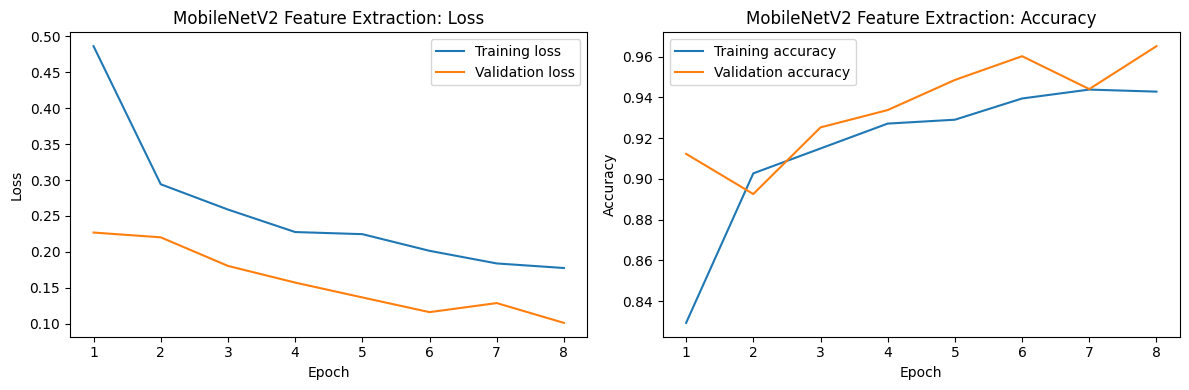

,accuracy,loss,val_accuracy,val_loss,learning_rate
3,0.927083,0.227678,0.933721,0.157345,0.001
4,0.928987,0.224736,0.948500,0.136688,0.001
5,0.939404,0.201540,0.960143,0.116206,0.001
6,0.943772,0.183986,0.944022,0.128833,0.001
7,0.942764,0.177620,0.965069,0.101260,0.001


88/88 ━━━━━━━━━━━━━━━━━━━━ 19s 168ms/step


,model,pseudo_test_loss,pseudo_test_accuracy,weighted_precision,weighted_recall,weighted_f1,training_time_seconds,training_time_minutes
0,MobileNetV2 Feature Extraction,0.09396,0.964171,0.964889,0.964171,0.964159,1255.454115,20.924235


              precision    recall  f1-score   support

    Cautions       0.89      0.94      0.92       334
   Crossings       0.94      0.89      0.91       364
   DIrection       0.98      1.00      0.99       593
    No Entry       0.96      0.99      0.97       586
  SpeedLimit       1.00      0.96      0.98       914

    accuracy                           0.96      2791
   macro avg       0.95      0.96      0.95      2791
weighted avg       0.96      0.96      0.96      2791



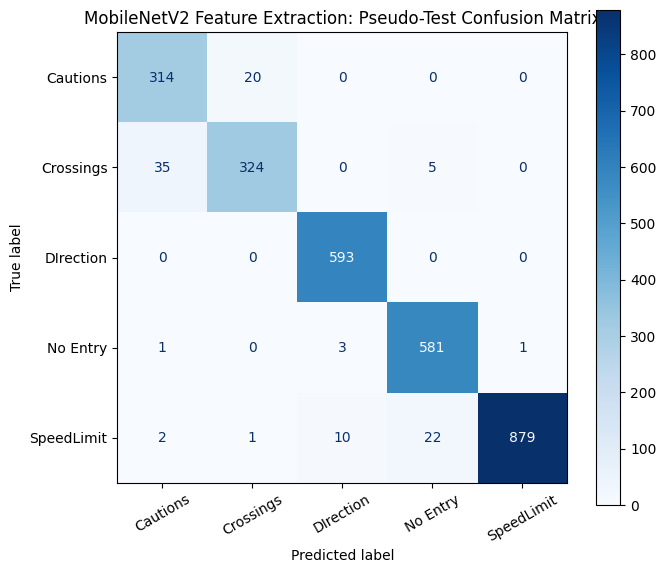

In [51]:
# Stage 1: feature extraction
transfer_history, transfer_time = fit_model(
    transfer_model,
    transfer_train_gen,
    transfer_val_gen,
    epochs=TRANSFER_EPOCHS,
    model_name='MobileNetV2 Feature Extraction',
    use_class_weight=True
)

plot_history(transfer_history, 'MobileNetV2 Feature Extraction')

transfer_metrics = evaluate_on_pseudo_test(
    transfer_model,
    transfer_pseudo_test_gen,
    'MobileNetV2 Feature Extraction',
    transfer_time
)

Epoch 1/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 174s 577ms/step - accuracy: 0.9549 - loss: 0.1457 - val_accuracy: 0.9695 - val_loss: 0.0819 - learning_rate: 1.0000e-05
Epoch 2/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 150s 537ms/step - accuracy: 0.9668 - loss: 0.1110 - val_accuracy: 0.9673 - val_loss: 0.0850 - learning_rate: 1.0000e-05
Epoch 3/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 151s 540ms/step - accuracy: 0.9766 - loss: 0.0867 - val_accuracy: 0.9772 - val_loss: 0.0551 - learning_rate: 1.0000e-05
Epoch 4/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 153s 549ms/step - accuracy: 0.9758 - loss: 0.0815 - val_accuracy: 0.9798 - val_loss: 0.0509 - learning_rate: 1.0000e-05
Epoch 5/5
279/279 ━━━━━━━━━━━━━━━━━━━━ 152s 545ms/step - accuracy: 0.9836 - loss: 0.0619 - val_accuracy: 0.9812 - val_loss: 0.0525 - learning_rate: 1.0000e-05
Restoring model weights from the end of the best epoch: 4.
MobileNetV2 Fine Tuned training time: 781.23 seconds (13.02 minutes)


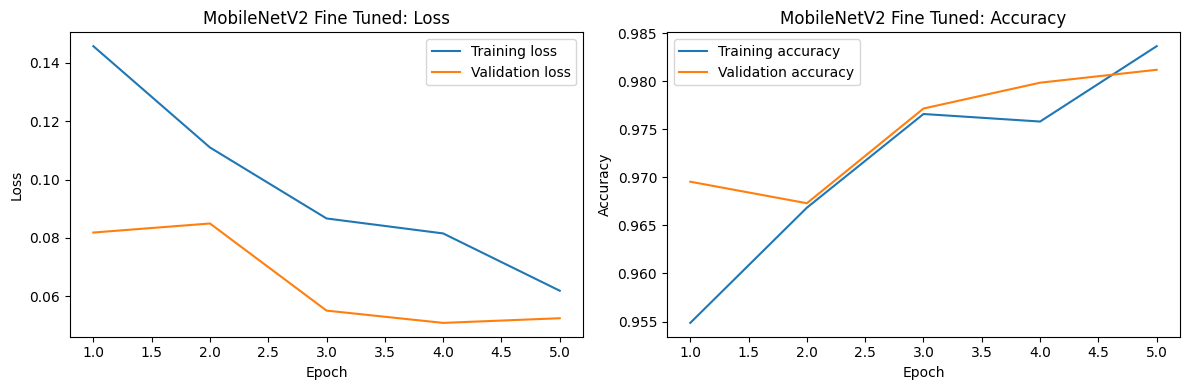

,accuracy,loss,val_accuracy,val_loss,learning_rate
0,0.954861,0.145731,0.969548,0.081851,0.00001
1,0.966846,0.111007,0.967309,0.084951,0.00001
2,0.976591,0.086674,0.977161,0.055089,0.00001
3,0.975806,0.081544,0.979848,0.050882,0.00001
4,0.983647,0.061903,0.981191,0.052474,0.00001


88/88 ━━━━━━━━━━━━━━━━━━━━ 21s 173ms/step


,model,pseudo_test_loss,pseudo_test_accuracy,weighted_precision,weighted_recall,weighted_f1,training_time_seconds,training_time_minutes
0,MobileNetV2 Fine Tuned,0.03918,0.987101,0.987234,0.987101,0.987117,781.231647,13.020527


              precision    recall  f1-score   support

    Cautions       0.95      0.98      0.96       334
   Crossings       0.98      0.96      0.97       364
   DIrection       0.99      1.00      1.00       593
    No Entry       0.99      0.99      0.99       586
  SpeedLimit       1.00      0.99      0.99       914

    accuracy                           0.99      2791
   macro avg       0.98      0.98      0.98      2791
weighted avg       0.99      0.99      0.99      2791



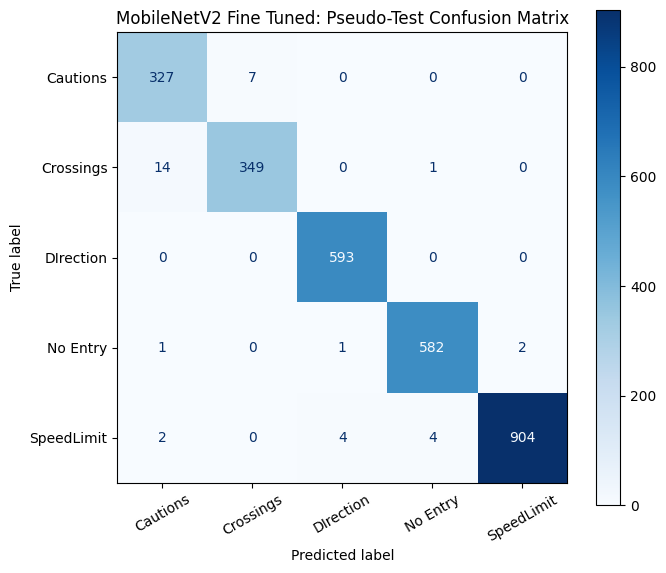

In [52]:
# Stage 2: fine-tuning the final layers with a low learning rate
mobilenet_base.trainable = True

for layer in mobilenet_base.layers[:-30]:
    layer.trainable = False
for layer in mobilenet_base.layers:
    if isinstance(layer, layers.BatchNormalization):
        layer.trainable = False

transfer_model.compile(optimizer=keras.optimizers.Adam(learning_rate=1e-5), loss='categorical_crossentropy', metrics=['accuracy'])

fine_tune_history, fine_tune_time = fit_model(
    transfer_model,
    transfer_train_gen,
    transfer_val_gen,
    epochs=FINE_TUNE_EPOCHS,
    model_name='MobileNetV2 Fine Tuned',
    use_class_weight=True
)
plot_history(fine_tune_history, 'MobileNetV2 Fine Tuned')
fine_tune_metrics = evaluate_on_pseudo_test(transfer_model, transfer_pseudo_test_gen, 'MobileNetV2 Fine Tuned', fine_tune_time)

### 2. Handling Input Size Differences:

* ImageNet models expect a specific input image size (e.g. 224 x 224 pixels for VGG, ResNet).
* Resize dataset images to match the required dimensions using appropriate Data Generator in Keras.

**Answer:** MobileNetV2 expects 224 x 224 RGB images, so the transfer-learning generators resize all images to 224 x 224 and apply MobileNetV2 preprocessing.

### 3. Handling Output Layer Differences:

* ImageNet trained models have a 1000 - class softmax output layer.
* Modify the final classification layer to match the number of classes in your dataset.

**Answer:** The ImageNet output layer is removed by setting include_top=False. A new softmax output layer with five neurons is added to match the five traffic sign classes.

## 2.6.3 Model Evaluation and Prediction:

* Evaluate the fine tuned model using the same performance metrics as in Part A.
* Make predictions on test data and compare results with the baseline and deeper models from Part A.
* Discuss whether transfer learning outperforms training from scratch for your dataset.

**Answer:** The transfer-learning model is evaluated on the pseudo-test set using the same metrics as Part A. Its performance is compared with the baseline CNN, deeper CNN, optimizer experiments, and ablation study.

,model,pseudo_test_loss,pseudo_test_accuracy,weighted_precision,weighted_recall,weighted_f1,training_time_seconds,training_time_minutes
0,Deeper CNN - SGD,0.072699,1.000000,1.000000,1.000000,1.000000,11.929857,0.198831
1,Deeper CNN - No Dropout Ablation,0.071894,0.999642,0.999643,0.999642,0.999642,651.217472,10.853625
2,Deeper Regularized CNN,0.077788,0.999283,0.999288,0.999283,0.999283,848.787990,14.146467
3,Baseline CNN,0.014711,0.996059,0.996098,0.996059,0.996060,780.939270,13.015655
4,Deeper CNN - Adam,0.086449,0.994267,0.994367,0.994267,0.994289,NaN,NaN
5,MobileNetV2 Fine Tuned,0.039180,0.987101,0.987234,0.987101,0.987117,781.231647,13.020527
6,MobileNetV2 Feature Extraction,0.093960,0.964171,0.964889,0.964171,0.964159,1255.454115,20.924235


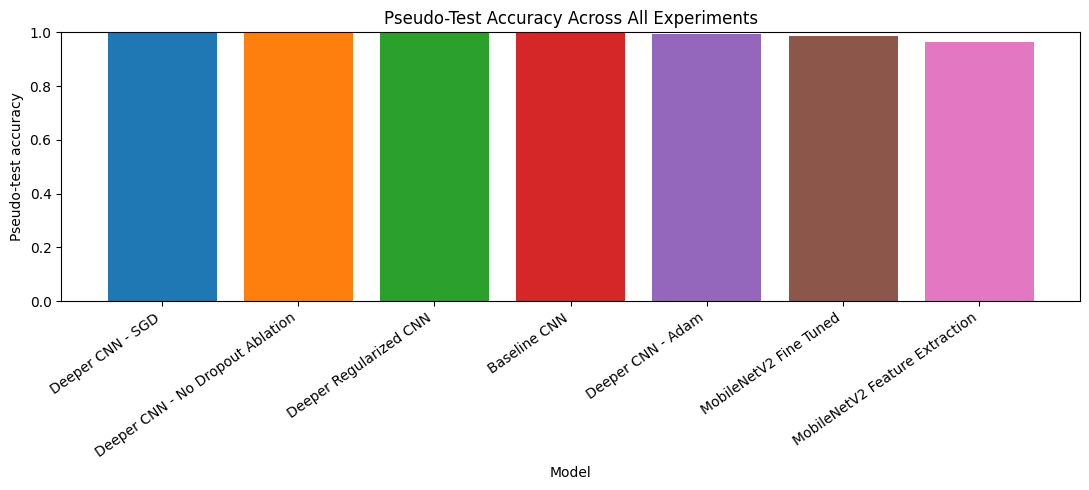

Saved all experiment results to: /content/drive/MyDrive/ai/notebook/outputs/all_vision_experiment_results.csv


In [53]:
# Compare all experiments and save final results
all_results_df = comparison_table()
display(all_results_df)

plt.figure(figsize=(11, 5))
if all_results_df.empty:
    print('Run the experiment cells before plotting the final comparison.')
else:
    plt.bar(all_results_df['model'], all_results_df['pseudo_test_accuracy'], color=sns.color_palette('tab10', len(all_results_df)))
    plt.title('Pseudo-Test Accuracy Across All Experiments')
    plt.xlabel('Model')
    plt.ylabel('Pseudo-test accuracy')
    plt.ylim(0, 1)
    plt.xticks(rotation=35, ha='right')
    plt.tight_layout()
    plt.show()

all_results_path = OUTPUT_DIR / 'all_vision_experiment_results.csv'
all_results_df.to_csv(all_results_path, index=False)
print('Saved all experiment results to:', all_results_path)

**Original Test Dataset Prediction:**

**Answer:** The original Test folder is unlabeled, so it is used only for qualitative prediction and demonstration. The predictions show the predicted class and confidence, but they are not used for quantitative metrics.

In [54]:
def predict_original_test_images(model, generator, image_df, output_name):
    generator.reset()
    probabilities = model.predict(generator, verbose=1)
    predicted_indices = np.argmax(probabilities, axis=1)
    confidences = np.max(probabilities, axis=1)

    predictions_df = image_df[['filename', 'filepath']].copy().reset_index(drop=True)
    predictions_df['predicted_class'] = [CLASS_NAMES[index] for index in predicted_indices]
    predictions_df['confidence'] = confidences

    output_path = OUTPUT_DIR / output_name
    predictions_df.to_csv(output_path, index=False)
    print('Saved qualitative predictions to:', output_path)
    display(predictions_df)
    return predictions_df

original_test_predictions_df = predict_original_test_images(
    transfer_model,
    transfer_original_test_gen,
    original_test_df,
    'original_unlabeled_test_predictions.csv'
)

1/1 ━━━━━━━━━━━━━━━━━━━━ 25s 25s/step
Saved qualitative predictions to: /content/drive/MyDrive/ai/notebook/outputs/original_unlabeled_test_predictions.csv


,filename,filepath,predicted_class,confidence
0,00004_00002_00011.png,/content/drive/.shortcut-targets-by-id/1gHVXr1...,SpeedLimit,0.990029
1,00008_00013_00018.png,/content/drive/.shortcut-targets-by-id/1gHVXr1...,SpeedLimit,0.999998
2,00014_00000_00002.png,/content/drive/.shortcut-targets-by-id/1gHVXr1...,No Entry,1.000000
3,00015_00002_00026.png,/content/drive/.shortcut-targets-by-id/1gHVXr1...,No Entry,0.999996
4,00021_00000_00000.png,/content/drive/.shortcut-targets-by-id/1gHVXr1...,Cautions,0.999161
5,00021_00000_00001.png,/content/drive/.shortcut-targets-by-id/1gHVXr1...,Cautions,0.999242
6,00027_00000_00002.png,/content/drive/.shortcut-targets-by-id/1gHVXr1...,Crossings,0.988708
7,00027_00000_00003.png,/content/drive/.shortcut-targets-by-id/1gHVXr1...,Crossings,0.953652
8,00036_00000_00001.png,/content/drive/.shortcut-targets-by-id/1gHVXr1...,DIrection,0.988775
9,00036_00000_00002.png,/content/drive/.shortcut-targets-by-id/1gHVXr1...,DIrection,0.980433


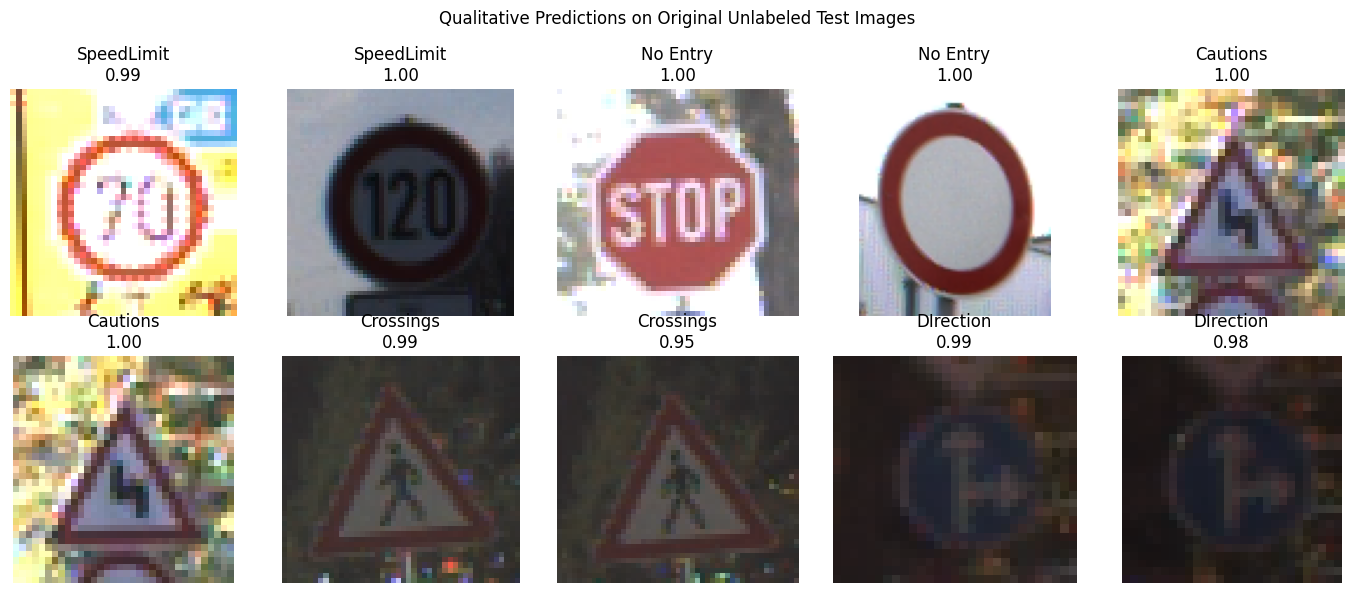

In [55]:
if len(original_test_predictions_df):
    plt.figure(figsize=(14, 6))
    for i, (_, row) in enumerate(original_test_predictions_df.head(10).iterrows(), start=1):
        image = Image.open(row['filepath']).convert('RGB')
        plt.subplot(2, 5, i)
        plt.imshow(image)
        plt.title(f"{row['predicted_class']}\n{row['confidence']:.2f}")
        plt.axis('off')
    plt.suptitle('Qualitative Predictions on Original Unlabeled Test Images')
    plt.tight_layout()
    plt.show()